# Day 1 — EDA & Data Cleaning
YouTube Real-Time Engagement Prediction Project

Goal for today:
1. Load and inspect the raw data
2. Check missing values and snapshot coverage per video
3. Visualize key patterns (EDA)
4. Clean the data (fill missing values properly, no shortcuts)
5. Save a clean version for Day 2 (feature engineering)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RAW_PATH = "C:/Users/Lenovo/youtube_enagagement_project/data/raw/youtube_realtime_history_aws_clean.csv"
PROCESSED_PATH = "C:Users/Lenovo/youtube_engagement_project/data/processed/cleaned_data.csv"

df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()

Shape: (80081, 15)


,video_id,title,channel,published_at,category_id,duration,views,likes,comments,snapshot_time,video_age_hours,views_per_hour,like_rate,comment_rate,engagement_rate
0,6rvUyBiBtik,Tera Mera Rishta Continues (Film Ballad)| Awar...,Sony Music India,2026-08-06 10:03:11+00:00,10.0,PT6M12S,3952422.0,168249.0,13058.0,2026-08-08 16:36:41.995733+05:30,49.058610,80565.30762,4.256858,0.330380,4.587238
1,6qdwBOT6MlE,"Vishwanath and Sons Trailer (Telugu) | Suriya,...",Sithara Entertainments,2026-08-07 11:37:04+00:00,24.0,PT2M50S,2807457.0,89991.0,1696.0,2026-08-08 16:36:41.995733+05:30,23.493888,119497.33630,3.205428,0.060411,3.265838
2,eyhpuALAiog,PMWC at EWC GROUP STAGE DAY 2 - WATCHPARTY WIT...,Snax Gaming,2026-08-07 16:07:38+00:00,20.0,PT5H30M56S,3766858.0,229832.0,388.0,2026-08-08 16:36:41.995733+05:30,18.984443,198418.14420,6.101425,0.010300,6.111725
3,qKw2Aajjkk0,#Video | बाबा के नयनवा | Power Star #Pawan Sin...,Maa Amma Films Bhakti,2026-08-07 04:15:26+00:00,10.0,PT3M24S,979988.0,95878.0,13487.0,2026-08-08 16:36:41.995733+05:30,30.854443,31761.64910,9.783589,1.376241,11.159831
4,hc6CE4Rnjjs,The Paradise - Hindi Teaser | Nani | Srikanth ...,Saregama Music,2026-08-06 12:47:22+00:00,24.0,PT1M43S,3091689.0,115851.0,7413.0,2026-08-08 16:36:41.995733+05:30,46.322221,66743.10797,3.747175,0.239772,3.986947


## 1. Basic inspection

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80081 entries, 0 to 80080
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   video_id         80081 non-null  str    
 1   title            80081 non-null  str    
 2   channel          80080 non-null  str    
 3   published_at     80079 non-null  str    
 4   category_id      80079 non-null  float64
 5   duration         80079 non-null  str    
 6   views            80079 non-null  float64
 7   likes            80079 non-null  float64
 8   comments         80079 non-null  float64
 9   snapshot_time    80079 non-null  str    
 10  video_age_hours  80079 non-null  float64
 11  views_per_hour   80079 non-null  float64
 12  like_rate        80079 non-null  float64
 13  comment_rate     80079 non-null  float64
 14  engagement_rate  80079 non-null  float64
dtypes: float64(9), str(6)
memory usage: 9.2 MB


In [5]:
df.isnull().sum()

video_id           0
title              0
channel            1
published_at       2
category_id        2
duration           2
views              2
likes              2
comments           2
snapshot_time      2
video_age_hours    2
views_per_hour     2
like_rate          2
comment_rate       2
engagement_rate    2
dtype: int64

Only a couple of fully-null rows — safe to drop them outright.

In [10]:
df = df.dropna(subset=["video_id", "video_age_hours"]).copy()
print("Shape after dropping null id/age rows:", df.shape)

Shape after dropping null id/age rows: (80079, 15)


## 2. Unique videos / channels / categories
Remember: 80k+ ROWS but far fewer unique VIDEOS (each video has many snapshots).
The number of unique videos is our real sample size for modeling later.

In [11]:
print("Unique videos:", df["video_id"].nunique())
print("Unique channels:", df["channel"].nunique())
print("Unique categories:", df["category_id"].nunique())

snapshots_per_video = df.groupby("video_id").size()
print("\nSnapshots per video — summary:")
print(snapshots_per_video.describe())

Unique videos: 563
Unique channels: 330
Unique categories: 9

Snapshots per video — summary:
count     563.000000
mean      142.236234
std       160.557866
min         1.000000
25%        22.000000
50%       111.000000
75%       203.500000
max      1664.000000
dtype: float64


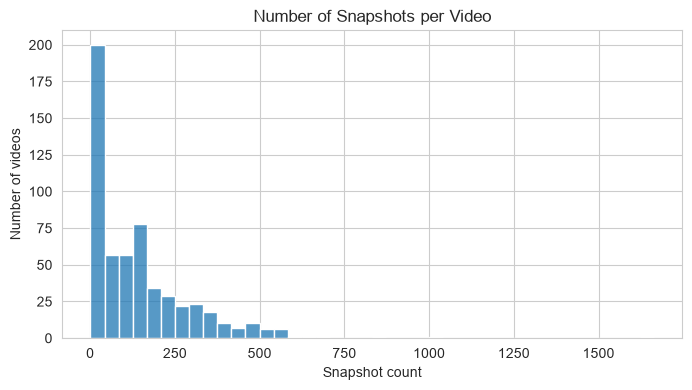

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(snapshots_per_video, bins=40)
plt.title("Number of Snapshots per Video")
plt.xlabel("Snapshot count")
plt.ylabel("Number of videos")
plt.show()

## 3. Missing-data heatmap
Visual check of where nulls occur (should be near-empty after our earlier dropna,
but useful to show in the report as evidence of the storage-gap issue).

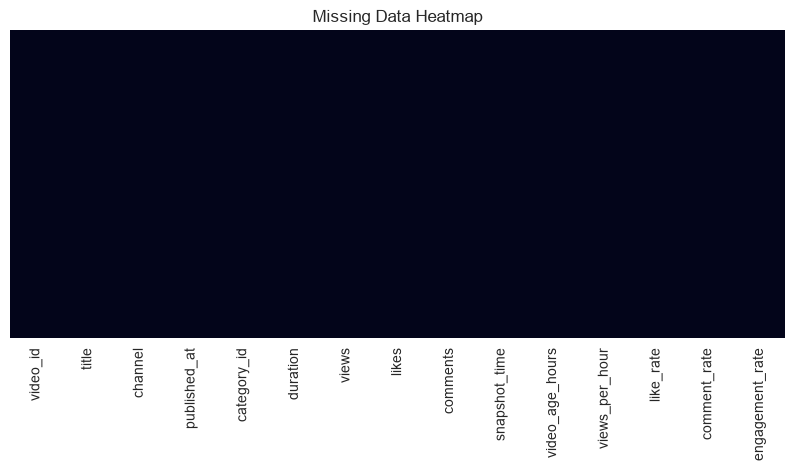

In [13]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

## 4. Engagement rate distribution
Expect a right-skewed distribution — most videos have low engagement,
a few have very high engagement (viral outliers).

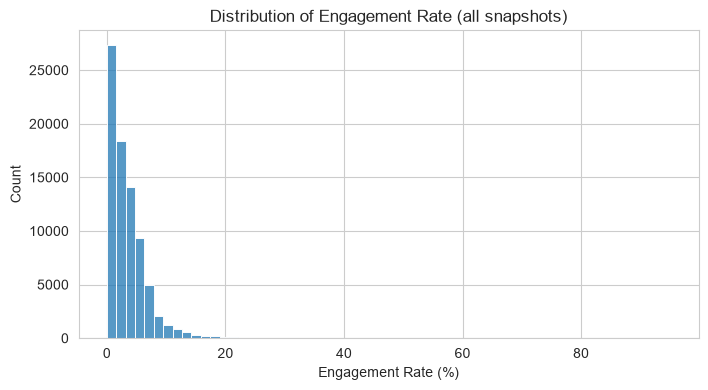

count    80079.000000
mean         3.438860
std          3.409184
min          0.000000
25%          1.083269
50%          2.603334
75%          4.780298
max         95.093458
Name: engagement_rate, dtype: float64


In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(df["engagement_rate"], bins=60)
plt.title("Distribution of Engagement Rate (all snapshots)")
plt.xlabel("Engagement Rate (%)")
plt.show()

print(df["engagement_rate"].describe())

## 5. Category-wise average engagement

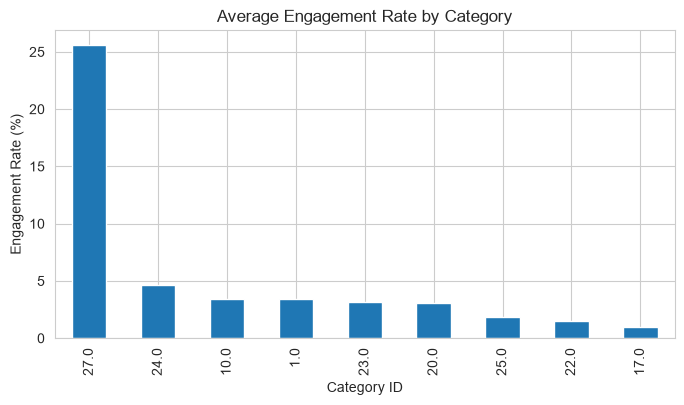

In [15]:
cat_avg = df.groupby("category_id")["engagement_rate"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
cat_avg.plot(kind="bar")
plt.title("Average Engagement Rate by Category")
plt.ylabel("Engagement Rate (%)")
plt.xlabel("Category ID")
plt.show()

## 6. Correlation heatmap — IMPORTANT (leakage check)
This should visually confirm: like_rate, comment_rate, views, likes, comments
are highly correlated with engagement_rate (since engagement_rate is derived
from them). These CANNOT be used as input features for prediction.

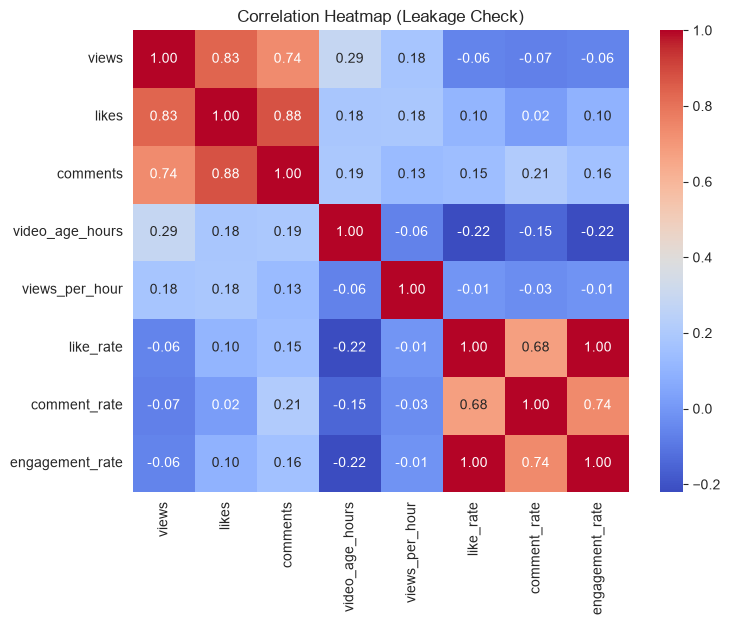

In [16]:
numeric_cols = ["views", "likes", "comments", "video_age_hours",
                 "views_per_hour", "like_rate", "comment_rate", "engagement_rate"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Leakage Check)")
plt.show()

## 7. Sample growth curve — pick a few videos and plot engagement over time
This is the visual that explains WHY we're doing early-window -> future-value
prediction instead of just using a single snapshot per video.

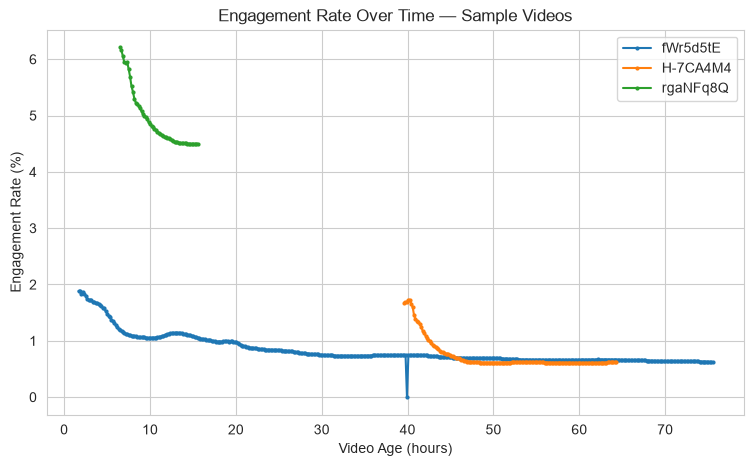

In [17]:
sample_ids = snapshots_per_video[snapshots_per_video > 50].sample(3, random_state=42).index

plt.figure(figsize=(9, 5))
for vid in sample_ids:
    vid_df = df[df["video_id"] == vid].sort_values("video_age_hours")
    plt.plot(vid_df["video_age_hours"], vid_df["engagement_rate"], marker="o", markersize=2, label=vid[:8])

plt.title("Engagement Rate Over Time — Sample Videos")
plt.xlabel("Video Age (hours)")
plt.ylabel("Engagement Rate (%)")
plt.legend()
plt.show()

## 8. Check target-window feasibility
Confirm how many videos have BOTH an early snapshot (<=6h) and a
"future" snapshot in the 18-30h window. This defines our final usable sample.

In [18]:
EARLY_CUTOFF = 6      # hours
TARGET_LOW, TARGET_HIGH = 18, 30   # hours

has_early = set(df[df["video_age_hours"] <= EARLY_CUTOFF]["video_id"].unique())
has_target = set(df[(df["video_age_hours"] >= TARGET_LOW) &
                     (df["video_age_hours"] <= TARGET_HIGH)]["video_id"].unique())
usable_videos = has_early & has_target

print(f"Videos with early snapshot (<= {EARLY_CUTOFF}h): {len(has_early)}")
print(f"Videos with target snapshot ({TARGET_LOW}-{TARGET_HIGH}h): {len(has_target)}")
print(f"Usable videos (both): {len(usable_videos)}")

Videos with early snapshot (<= 6h): 275
Videos with target snapshot (18-30h): 331
Usable videos (both): 163


## 9. Cleaning
Strategy:
- Sort by video_id + snapshot time
- Static fields (title, channel, category_id, duration, published_at):
  fill forward/backward within each video group (they shouldn't change)
- Counters (views, likes, comments): forward-fill within each video
  (monotonically non-decreasing, so last known value is a fair estimate)
- Derived ratios (like_rate, comment_rate, engagement_rate): RECOMPUTE
  after filling raw counts, rather than filling the ratios directly

In [19]:
df["published_at"] = pd.to_datetime(df["published_at"], utc=True)
df["snapshot_time"] = pd.to_datetime(df["snapshot_time"], utc=True)

df = df.sort_values(["video_id", "snapshot_time"]).reset_index(drop=True)

static_cols = ["title", "channel", "category_id", "duration", "published_at"]
for col in static_cols:
    df[col] = df.groupby("video_id")[col].transform(lambda x: x.ffill().bfill())

count_cols = ["views", "likes", "comments"]
for col in count_cols:
    df[col] = df.groupby("video_id")[col].transform(lambda x: x.ffill().bfill())

# Recompute derived ratios (avoid using possibly-stale filled ratio values)
df["like_rate"] = (df["likes"] / df["views"]) * 100
df["comment_rate"] = (df["comments"] / df["views"]) * 100
df["engagement_rate"] = ((df["likes"] + df["comments"]) / df["views"]) * 100

print("Remaining nulls after cleaning:")
print(df.isnull().sum())

Remaining nulls after cleaning:
video_id           0
title              0
channel            0
published_at       0
category_id        0
duration           0
views              0
likes              0
comments           0
snapshot_time      0
video_age_hours    0
views_per_hour     0
like_rate          0
comment_rate       0
engagement_rate    0
dtype: int64


## 10. Parse duration (ISO 8601, e.g. PT6M12S) into seconds
Needed as a numeric feature for Day 2.

In [20]:
import re

def parse_duration_to_seconds(duration_str):
    if pd.isna(duration_str):
        return np.nan
    match = re.match(r"PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?", str(duration_str))
    if not match:
        return np.nan
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    return hours * 3600 + minutes * 60 + seconds

df["duration_seconds"] = df["duration"].apply(parse_duration_to_seconds)
df[["duration", "duration_seconds"]].drop_duplicates().head()

,duration,duration_seconds
0,PT4M14S,254
70,PT11M13S,673
86,PT4M39S,279
536,PT3H6M3S,11163
621,PT1H5M25S,3925


## 11. Keep only videos usable for our modeling design
(has both an early snapshot and a target-window snapshot)

In [21]:
df_clean = df[df["video_id"].isin(usable_videos)].copy()
print("Rows before filtering to usable videos:", df.shape[0])
print("Rows after filtering:", df_clean.shape[0])
print("Unique usable videos:", df_clean["video_id"].nunique())

Rows before filtering to usable videos: 80079
Rows after filtering: 43151
Unique usable videos: 163


## 12. Save cleaned data for Day 2

In [24]:
import os

RAW_PATH = r"C:\Users\Lenovo\youtube_engagement_project\data\raw\youtube_realtime_history_aws_clean.csv"
PROCESSED_PATH = r"C:\Users\Lenovo\youtube_engagement_project\data\processed\cleaned_data.csv"

os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
df_clean.to_csv(PROCESSED_PATH, index=False)
print(f"Saved cleaned data to {PROCESSED_PATH}")
print(df_clean.shape)

Saved cleaned data to C:\Users\Lenovo\youtube_engagement_project\data\processed\cleaned_data.csv
(43151, 16)


In [25]:
df_clean.head()

,video_id,title,channel,published_at,category_id,duration,views,likes,comments,snapshot_time,video_age_hours,views_per_hour,like_rate,comment_rate,engagement_rate,duration_seconds
0,#NAME?,CHUTTU MUTTU HYDERABAD | TELANGANA FOLK HIT 2...,SVC Recording Company,2026-08-07 14:07:54+00:00,10.0,PT4M14S,41846.0,455.0,11.0,2026-08-09 14:41:47.330205+00:00,48.564814,861.652637,1.087320,0.026287,1.113607,254
1,#NAME?,CHUTTU MUTTU HYDERABAD | TELANGANA FOLK HIT 2...,SVC Recording Company,2026-08-07 14:07:54+00:00,10.0,PT4M14S,42149.0,457.0,11.0,2026-08-09 14:51:47.864706+00:00,48.731629,864.920808,1.084249,0.026098,1.110347,254
2,#NAME?,CHUTTU MUTTU HYDERABAD | TELANGANA FOLK HIT 2...,SVC Recording Company,2026-08-07 14:07:54+00:00,10.0,PT4M14S,42526.0,460.0,11.0,2026-08-09 15:01:48.491413+00:00,48.898470,869.679565,1.081691,0.025867,1.107558,254
3,#NAME?,CHUTTU MUTTU HYDERABAD | TELANGANA FOLK HIT 2...,SVC Recording Company,2026-08-07 14:07:54+00:00,10.0,PT4M14S,42893.0,460.0,11.0,2026-08-09 15:11:48.984515+00:00,49.065273,874.202811,1.072436,0.025645,1.098081,254
4,#NAME?,CHUTTU MUTTU HYDERABAD | TELANGANA FOLK HIT 2...,SVC Recording Company,2026-08-07 14:07:54+00:00,10.0,PT4M14S,43349.0,463.0,11.0,2026-08-09 15:21:49.758017+00:00,49.232155,880.501778,1.068075,0.025375,1.093451,254


In [26]:
df_clean.dtypes

video_id                            str
title                               str
channel                             str
published_at        datetime64[us, UTC]
category_id                     float64
duration                            str
views                           float64
likes                           float64
comments                        float64
snapshot_time       datetime64[us, UTC]
video_age_hours                 float64
views_per_hour                  float64
like_rate                       float64
comment_rate                    float64
engagement_rate                 float64
duration_seconds                  int64
dtype: object

In [27]:
df_clean['video_id'].nunique()

163

In [28]:
print((df_clean['video_id'] == '#NAME?').sum())

1664


In [29]:

# How many unique videos does this affect?
print(df_clean[df_clean['video_id'] == '#NAME?']['title'].nunique())

11


In [30]:
print("Before:", df_clean.shape, df_clean['video_id'].nunique())

df_clean = df_clean[df_clean['video_id'] != '#NAME?'].copy()

print("After:", df_clean.shape, df_clean['video_id'].nunique())

Before: (43151, 16) 163
After: (41487, 16) 162


In [31]:
print(df_clean.shape)
print(df_clean['video_id'].nunique())
df_clean.to_csv(PROCESSED_PATH, index=False)

(41487, 16)
162
